# Tratamento dos dados

Dado que uma rede MLP espera como entrada um vetor unidimensional de características, é necessário adequar a representação das imagens da base de dados para esse formato.

Para isso, aplicaram-se as seguintes etapas de pré-processamento:

1. Conversão das imagens de RGB para escala de cinza, removendo os canais de cor e mantendo apenas a intensidade dos pixels, o que reduz a dimensionalidade dos dados.

2. *Flatten* das imagens para representação em linha, transformando a matriz bidimensional da imagem em um vetor unidimensional de características.

In [1]:
# Imports

from keras.datasets import cifar10
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import set_random_seed, to_categorical
from keras.optimizers import Adam

set_random_seed(259)

I0000 00:00:1776263640.072198  106840 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776263640.178509  106840 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776263642.762513  106840 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Carregamento dos dados

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print('Train Images Shape:      ', x_train.shape)
print('Train Labels Shape:      ', y_train.shape)

print('\nTest Images Shape:       ', x_test.shape)
print('Test Labels Shape:       ', y_test.shape)

Train Images Shape:       (50000, 32, 32, 3)
Train Labels Shape:       (50000, 1)

Test Images Shape:        (10000, 32, 32, 3)
Test Labels Shape:        (10000, 1)


/home/vitor/.pyenv/versions/JupyterNotebooks/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


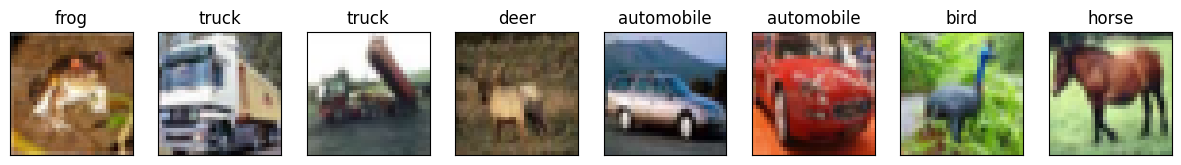

In [3]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 8 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train[i])

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [4]:
# Conversão das imagens de RGB para escala de cinza

# fórmula padrão: Y = 0.299 R + 0.587 G + 0.114 B
x_train_gray = np.dot(x_train[..., :3], [0.299, 0.587, 0.114])
x_test_gray = np.dot(x_test[..., :3], [0.299, 0.587, 0.114])

print('Train Images Shape (Gray scale):      ', x_train_gray.shape)
print('Test Images Shape (Gray scale):       ', x_test_gray.shape)

Train Images Shape (Gray scale):       (50000, 32, 32)
Test Images Shape (Gray scale):        (10000, 32, 32)


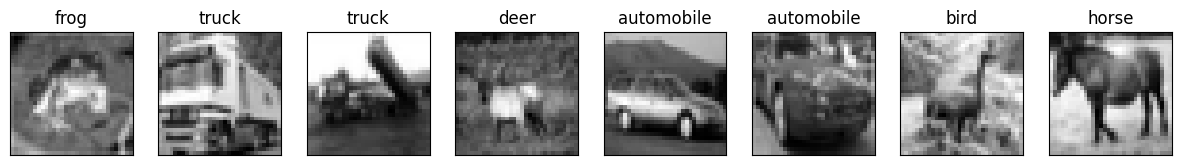

In [5]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 8 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train_gray[i], cmap='gray')

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [6]:
# Flatten das imagens e normalização [0, 1] (melhora estabilidade e acurácia)

x_train_flat = x_train_gray.reshape(x_train_gray.shape[0], -1).astype('float32') / 255.0
x_test_flat = x_test_gray.reshape(x_test_gray.shape[0], -1).astype('float32') / 255.0

x_train_df = pd.DataFrame(x_train_flat)
x_test_df = pd.DataFrame(x_test_flat)

print('Train Images Shape (Gray scale & Flatten):      ', x_train_df.shape)
print('Test Images Shape (Gray scale & Flatten):       ', x_test_df.shape)

# Conversão dos rótulos para one-hot encoding

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

Train Images Shape (Gray scale & Flatten):       (50000, 1024)
Test Images Shape (Gray scale & Flatten):        (10000, 1024)


# Estrutura da rede

In [7]:
# Hiper-parâmetros

input_shape = 1024                  # 32 x 32 x 1
epochs = 50                         # https://keras.io/examples/vision/mlp_image_classification/
batch_size = 128                    # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw
dropout_rate = 0.2                  # https://keras.io/examples/vision/mlp_image_classification/
learning_rate = 0.001               # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw

#Outras Fontes
#https://pvss.github.io/MLP+of+CIFAR-10
#https://www.kaggle.com/code/yorkyong/exploring-cifar-10-w-mlp-cnn-resnet

In [8]:
# Construção do modelo MLP

# Estutura baseada no artigo
# "UTILIZAÇÃO DE REDES NEURAIS ARTIFICIAIS PARA A CLASSIFICAÇÃO DECORROSÃO POR PITE OBSERVADAS EM IMAGENS OBTIDAS COM O ENSAIO NÃO INVASIVO DE QUEDA DE POTENCIAL"
# de GABRIEL PEREIRA HOLANDA BARRETO (https://repositorio.ufc.br/bitstream/riufc/83115/1/2025_tcc_gphbarreto.pdf)

def create_model_1():

    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_shape,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    return model

# Experimento 1 - Sem dropout e sem early stop

In [ ]:
# Treinamento e avaliação do modelo

histories = []

for i in range(3):
    model_1 = create_model_1()

    history = model_1.fit(
        x_train_df.values,
        y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=1,
    )

    histories.append(history)

    train_acc = history.history['accuracy'][-1] 

    loss, acc = model_1.evaluate(
        x_test_df.values,
        y_test_cat,
        verbose=0
    )

    print(f'Execução {i+1} | Treino — acurácia: {train_acc:.4f} | Teste — loss: {loss:.4f}, acurácia: {acc:.4f}')

/home/vitor/.pyenv/versions/JupyterNotebooks/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1776263649.746898  106840 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2340 - loss: 2.0918 - val_accuracy: 0.2824 - val_loss: 2.0202
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2943 - loss: 1.9597 - val_accuracy: 0.3056 - val_loss: 1.9410
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3219 - loss: 1.8966 - val_accuracy: 0.3352 - val_loss: 1.8854
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3357 - loss: 1.8585 - val_accuracy: 0.3424 - val_loss: 1.8509
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3454 - loss: 1.8318 - val_accuracy: 0.3510 - val_loss: 1.8248
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3557 - loss: 1.8081 - val_accuracy: 0.3530 - val_loss: 1.8113
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3620 - loss: 1.7904 - val_accuracy: 0.3578 - val_loss: 1.8005
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3671 - loss: 1.7770 - val_accuracy: 0.

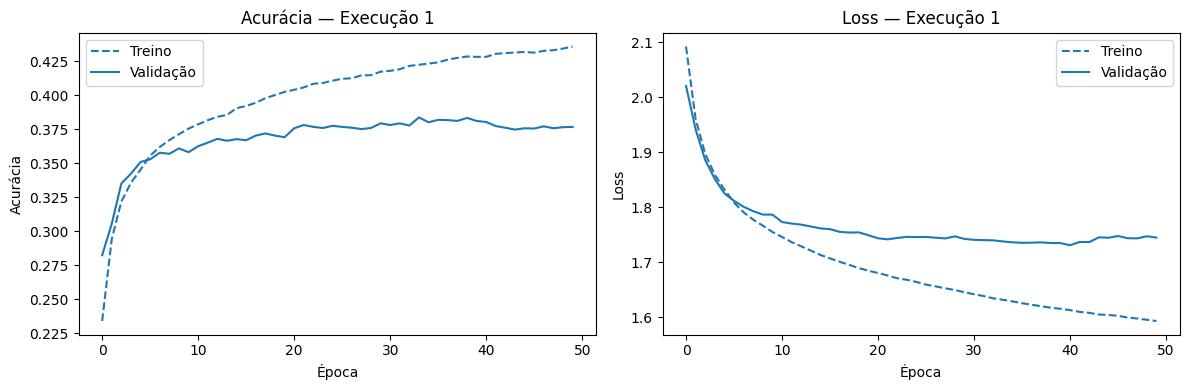

Execução 1:
  Treino     — loss: 1.5928, acurácia: 0.4359
  Validação  — loss: 1.7445, acurácia: 0.3768
  Gap de generalização (val_loss - train_loss): 0.1517



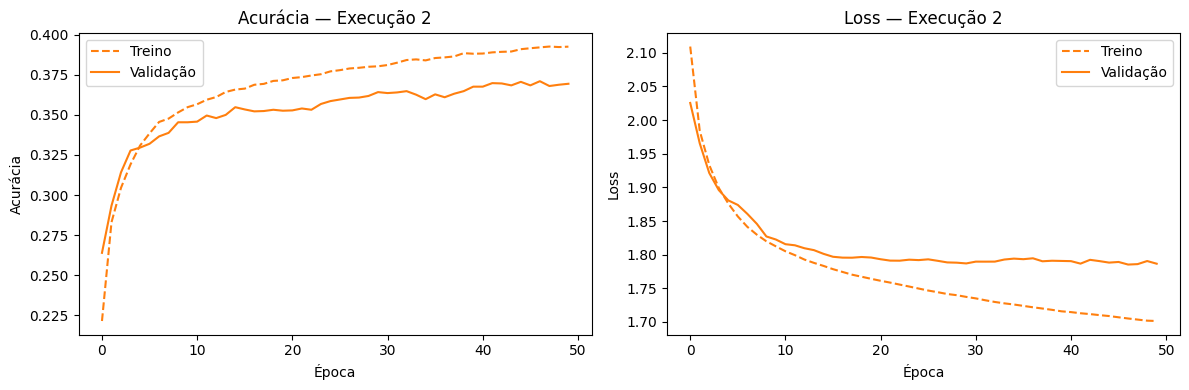

Execução 2:
  Treino     — loss: 1.7014, acurácia: 0.3925
  Validação  — loss: 1.7865, acurácia: 0.3694
  Gap de generalização (val_loss - train_loss): 0.0852



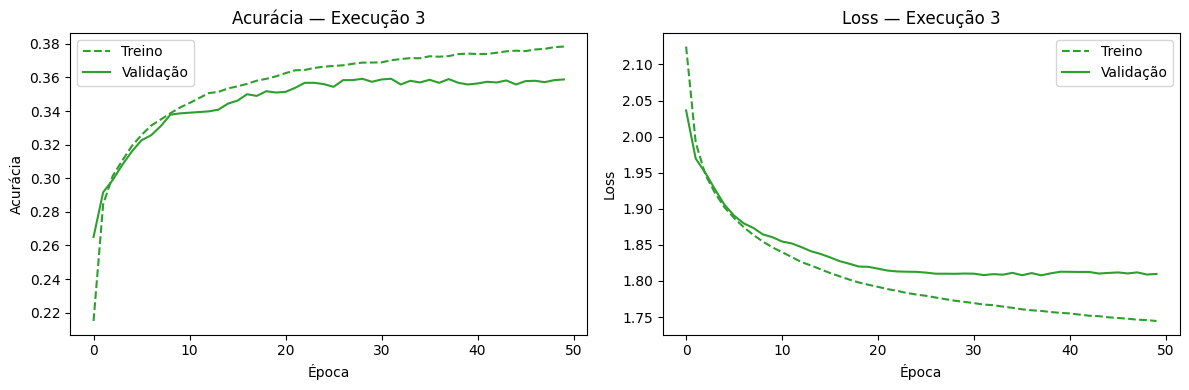

Execução 3:
  Treino     — loss: 1.7445, acurácia: 0.3784
  Validação  — loss: 1.8098, acurácia: 0.3588
  Gap de generalização (val_loss - train_loss): 0.0652



In [10]:
def show_results(histories):
    import matplotlib.pyplot as plt

    colors = plt.cm.tab10.colors

    for i, history in enumerate(histories):

        color = colors[i % len(colors)]

        fig, axes = plt.subplots(1, 2, figsize=(12,4))

        # ---------------------------
        # Acurácia
        # ---------------------------
        axes[0].plot(
            history.history['accuracy'],
            '--',
            color=color,
            label='Treino'
        )

        axes[0].plot(
            history.history['val_accuracy'],
            '-',
            color=color,
            label='Validação'
        )

        axes[0].set_title(f'Acurácia — Execução {i+1}')
        axes[0].set_xlabel('Época')
        axes[0].set_ylabel('Acurácia')
        axes[0].legend()

        # ---------------------------
        # Loss
        # ---------------------------
        axes[1].plot(
            history.history['loss'],
            '--',
            color=color,
            label='Treino'
        )

        axes[1].plot(
            history.history['val_loss'],
            '-',
            color=color,
            label='Validação'
        )

        axes[1].set_title(f'Loss — Execução {i+1}')
        axes[1].set_xlabel('Época')
        axes[1].set_ylabel('Loss')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        # ---------------------------
        # Resultados finais
        # ---------------------------
        final_train_loss = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]

        final_train_acc = history.history['accuracy'][-1]
        final_val_acc = history.history['val_accuracy'][-1]

        loss_gap = final_val_loss - final_train_loss

        print(f'Execução {i+1}:')
        print(f'  Treino     — loss: {final_train_loss:.4f}, acurácia: {final_train_acc:.4f}')
        print(f'  Validação  — loss: {final_val_loss:.4f}, acurácia: {final_val_acc:.4f}')
        print(f'  Gap de generalização (val_loss - train_loss): {loss_gap:.4f}')
        print()

show_results(histories)

# Experimento 2 - Sem dropout e com early stop

In [ ]:
# Treinamento

from keras.callbacks import EarlyStopping

histories = []

for i in range(3):
    model_1 = create_model_1()

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
    )

    history = model_1.fit(
        x_train_df.values,
        y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=1,
        callbacks=[early_stop]
    )

    histories.append(history)

    train_acc = history.history['accuracy'][-1] 

    loss, acc = model_1.evaluate(
        x_test_df.values,
        y_test_cat,
        verbose=0
    )

    print(f'Execução {i+1} | Treino — acurácia: {train_acc:.4f} | Teste — loss: {loss:.4f}, acurácia: {acc:.4f}')

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2291 - loss: 2.0943 - val_accuracy: 0.2766 - val_loss: 2.0055
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2958 - loss: 1.9588 - val_accuracy: 0.3082 - val_loss: 1.9365
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3124 - loss: 1.9159 - val_accuracy: 0.3220 - val_loss: 1.9073
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3231 - loss: 1.8888 - val_accuracy: 0.3318 - val_loss: 1.8850
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3322 - loss: 1.8649 - val_accuracy: 0.3344 - val_loss: 1.8693
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3396 - loss: 1.8463 - val_accuracy: 0.3338 - val_loss: 1.8573
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3469 - loss: 1.8317 - val_accuracy: 0.3448 - val_loss: 1.8429
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3516 - loss: 1.8197 - val_accuracy: 0.

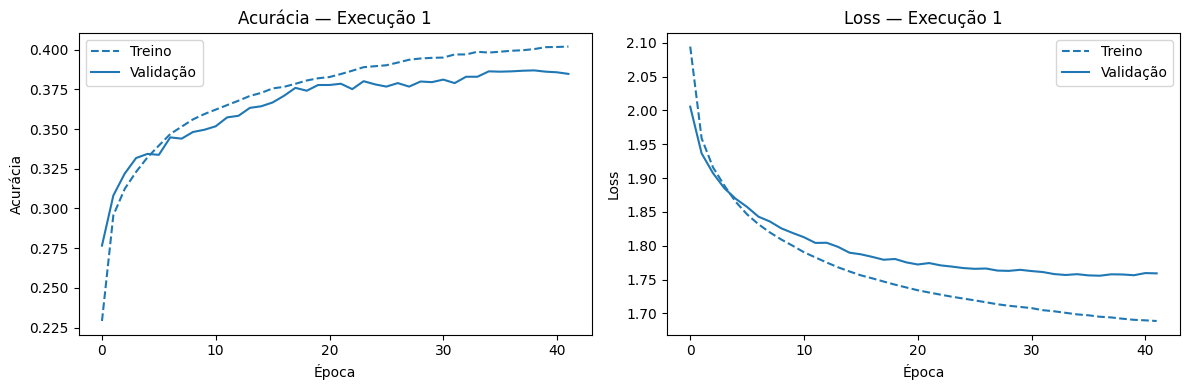

Execução 1:
  Treino     — loss: 1.6888, acurácia: 0.4020
  Validação  — loss: 1.7592, acurácia: 0.3848
  Gap de generalização (val_loss - train_loss): 0.0704



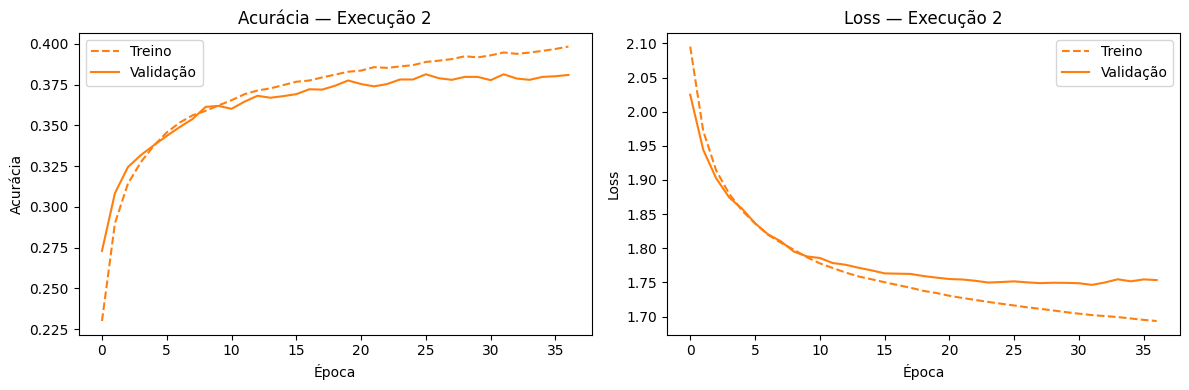

Execução 2:
  Treino     — loss: 1.6936, acurácia: 0.3984
  Validação  — loss: 1.7535, acurácia: 0.3810
  Gap de generalização (val_loss - train_loss): 0.0599



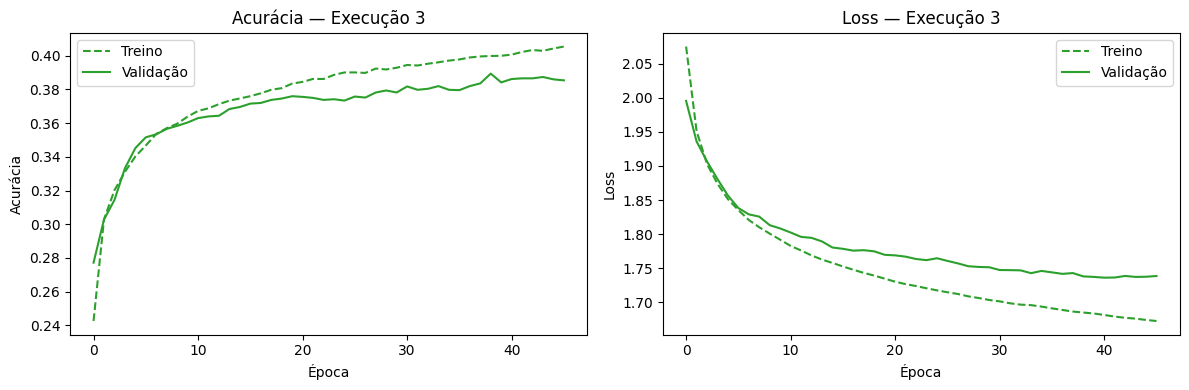

Execução 3:
  Treino     — loss: 1.6726, acurácia: 0.4055
  Validação  — loss: 1.7386, acurácia: 0.3854
  Gap de generalização (val_loss - train_loss): 0.0660



In [13]:
# Resutados
show_results(histories)

# Experimento 3 - Com dropout e sem early stop

In [14]:
# Treinamento

def create_model_2():

    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    return model

In [ ]:
# Treinamento e avaliação do modelo

histories = []

for i in range(3):
    model_2 = create_model_2()

    history = model_2.fit(
        x_train_df.values,
        y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=1,
    )

    histories.append(history)

    train_acc = history.history['accuracy'][-1] 

    loss, acc = model_1.evaluate(
        x_test_df.values,
        y_test_cat,
        verbose=0
    )

    print(f'Execução {i+1} | Treino — acurácia: {train_acc:.4f} | Teste — loss: {loss:.4f}, acurácia: {acc:.4f}')

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1550 - loss: 2.2132 - val_accuracy: 0.2172 - val_loss: 2.1332
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1967 - loss: 2.1438 - val_accuracy: 0.2424 - val_loss: 2.0923
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2113 - loss: 2.1164 - val_accuracy: 0.2552 - val_loss: 2.0702
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2177 - loss: 2.1058 - val_accuracy: 0.2616 - val_loss: 2.0504
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2206 - loss: 2.1003 - val_accuracy: 0.2432 - val_loss: 2.0633
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2229 - loss: 2.0898 - val_accuracy: 0.2572 - val_loss: 2.0390
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2257 - loss: 2.0796 - val_accuracy: 0.2554 - val_loss: 2.0368
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2324 - loss: 2.0696 - val_accuracy: 0.

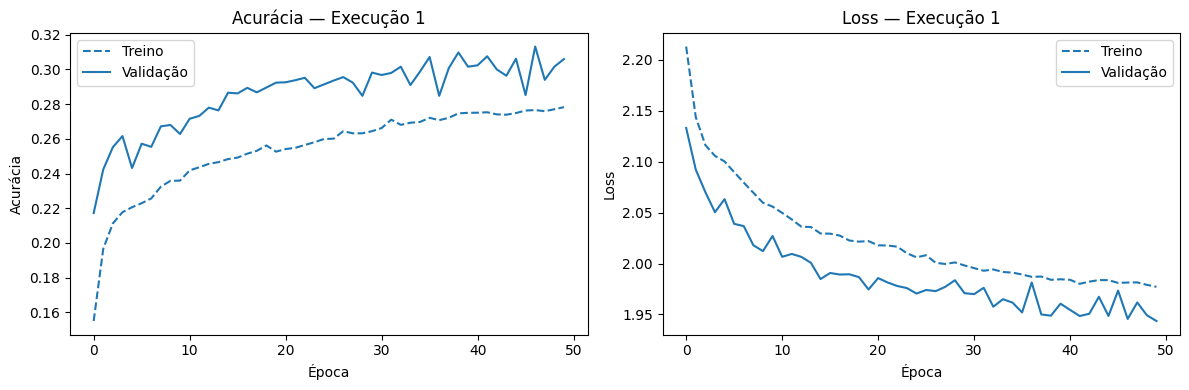

Execução 1:
  Treino     — loss: 1.9772, acurácia: 0.2783
  Validação  — loss: 1.9436, acurácia: 0.3060
  Gap de generalização (val_loss - train_loss): -0.0336



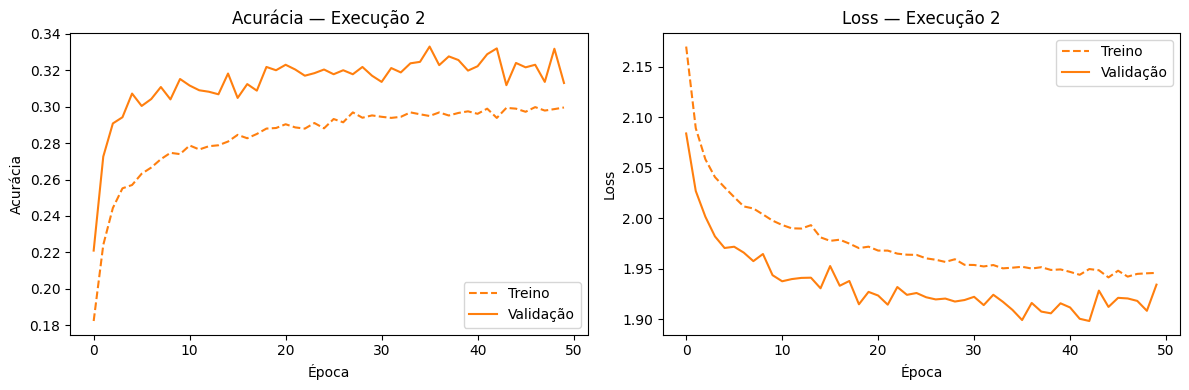

Execução 2:
  Treino     — loss: 1.9457, acurácia: 0.2996
  Validação  — loss: 1.9340, acurácia: 0.3130
  Gap de generalização (val_loss - train_loss): -0.0116



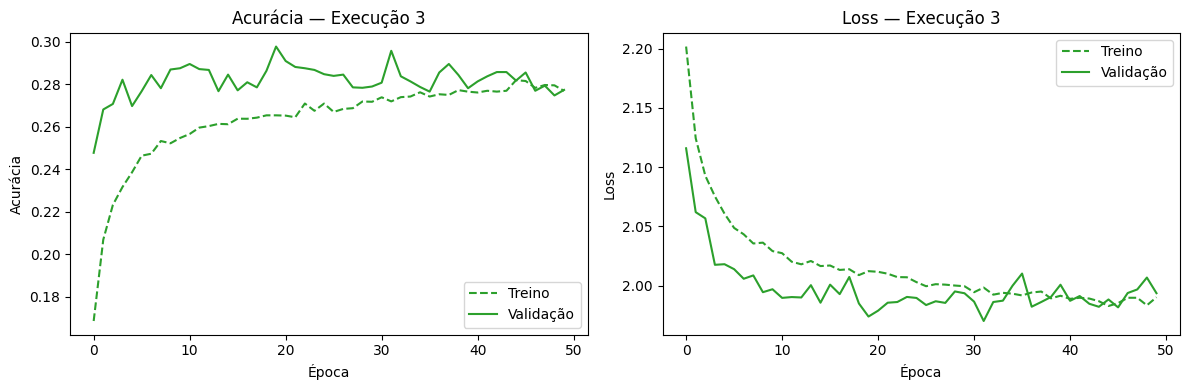

Execução 3:
  Treino     — loss: 1.9901, acurácia: 0.2770
  Validação  — loss: 1.9935, acurácia: 0.2774
  Gap de generalização (val_loss - train_loss): 0.0035



In [17]:
# Resultados
show_results(histories)

# Experimento 4 - Com dropout e com early stop

In [ ]:
# Treinamento

In [ ]:
# Resultados